In [1]:
import sys
from functools import partial
sys.path.append('../')
from math import log, comb, cos, sin
from numpy.linalg import matrix_power
from spd.OperatorSequence import *
from spd.SparsePauliDynamics import *
from spd.LightPauliDynamics import *
from pauli import *
from quantity import * 
from quantum_simulation_recipe.spin import Nearest_Neighbour_1d
from quantum_simulation_recipe.trotter import pf, expH
from qiskit.quantum_info import SparsePauliOp, random_statevector, Statevector
import matplotlib.pyplot as plt
from quantum_simulation_recipe.plot_config import *
set_fontsize(linewidth=2.5)
fig_dir, data_dir = './figs', './data'

## Parameters

In [2]:
n = 10 # 10
t = 10  
r = 100 # 100

dt = t/r
# H_model = 'MFI'
# hx, hy, Jx = 1, 0.9, 0.8
Jx, hx, hy = 1, 0.8, 0.9
print(f't={t}, r={r}, dt={dt}')

# init_state_str = '0'*n
init_state_str = '10'*(n//2)
init_state = Statevector.from_label(init_state_str).data

z1 = SparsePauliOp('I'*(n-1)+'Z', 1)
ob_op = z1
obs = ob_op.to_matrix()
complete_fnorm = 2**(-n/2)*np.linalg.norm(obs, ord='fro')

t=10, r=100, dt=0.1


## Ideal evolution

In [3]:
## QMFI
qmfi = Nearest_Neighbour_1d(n, hx=hx, hy=hy, Jx=Jx, pbc=False)
qmfi_xx_even = SparsePauliOp.from_sparse_list([*qmfi.xx_tuples[::2]], num_qubits=n).simplify()
qmfi_xx_odd = SparsePauliOp.from_sparse_list([*qmfi.xx_tuples[1::2]], num_qubits=n).simplify()
qmfi_x_terms = SparsePauliOp.from_sparse_list([*qmfi.x_tuples], num_qubits=n).simplify()
qmfi_y_terms = qmfi.y_terms
qmfi_H_list = [qmfi_y_terms, qmfi_x_terms, qmfi_xx_even, qmfi_xx_odd]   # y before x is better
qmfi_H_ordered = sum(qmfi_H_list)
qmfi_U_dt_ideal = expH(sum(qmfi_H_ordered), dt, use_jax=False)
qmfi_U_dt_appro = pf(qmfi_H_ordered, dt, 1, 1)

qmfi_ideal_ops = [matrix_power(qmfi_U_dt_ideal, i) for i in range(r+1)]
qmfi_trott_ops = [matrix_power(qmfi_U_dt_appro, i) for i in range(r+1)]

print('evoluate states...')
qmfi_ideal_states = [qmfi_ideal_ops[i]@init_state for i in range(r+1)]
qmfi_trott_states = [qmfi_trott_ops[i]@init_state for i in range(r+1)]
print('evoluate obs...')
qmfi_trott_obs = [op.conjugate().transpose() @ obs @ op for op in qmfi_trott_ops]
qmfi_ideal_obs = [op.conjugate().transpose() @ obs @ op for op in qmfi_ideal_ops]
print('evoluate expvals...')
qmfi_ideal_expvals = [expect_value(obs, qmfi_ideal_states[i]) for i in range(r+1)]
qmfi_trott_expvals = [expect_value(obs, qmfi_trott_states[i]) for i in range(r+1)]

qmfi_ops = dt*sum(qmfi_H_list)
# print('ops:', ops)
# print('obs:', obs)

evoluate states...
evoluate obs...
evoluate expvals...


## MPS

In [4]:
from qiskit_aer import AerSimulator
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter
from qiskit_aer.library import save_statevector, save_density_matrix
from qiskit import QuantumCircuit, transpile

# We create an empty circuit
def create_circuit(n, gate_list, init_state=None, save_statevector=True, repeat=1, draw=-1):
    circuit = QuantumCircuit(n)
    if init_state is not None:
        circuit.set_statevector(init_state)
        circuit.save_statevector(label='0')
    for d in range(1,repeat):
        for gate in gate_list:
            circuit.append(gate, range(n))
        if save_statevector:
            circuit.save_statevector(label=f'{d}')
    # if draw != -1 and n <= 6:
    #     circuit.decompose(reps=draw).draw('mpl')
    # circ_pf1_eo = transpile(circ_pf1_eo, optimization_level=0)
    return circuit

pf1_xx_e = PauliEvolutionGate(qmfi_xx_even, dt, synthesis=LieTrotter())
pf1_xx_o = PauliEvolutionGate(qmfi_xx_odd, dt, synthesis=LieTrotter())
pf1_x = PauliEvolutionGate(qmfi_x_terms, dt, synthesis=LieTrotter())
pf1_y = PauliEvolutionGate(qmfi.y_terms, dt, synthesis=LieTrotter())
gate_list = [pf1_y, pf1_x, pf1_xx_e, pf1_xx_o]
circ_pf1 = create_circuit(qmfi.n, gate_list, init_state=init_state, repeat=r+1)
sim_mps16 = AerSimulator(method='matrix_product_state', matrix_product_state_truncation_threshold=1e-19, matrix_product_state_max_bond_dimension=32)
res_mps16 = sim_mps16.run(circ_pf1.decompose()).result().data()
expvals_mps16 = [expect_value(obs, res_mps16[str(d)].data) for d in range(r+1)]

## LPD

In [6]:
exp_val_func = partial(exp_val_0101_state_pauli_rep, n_qubits=n)
# exp_val_func = exp_val_all_zeros_pauli_rep

w_thres = 5
qmfi_sim = LowWeightPauliPropagation.from_pauli_list(ob_op, qmfi_ops, threshold=w_thres, nprocs=4)
qmfi_res = qmfi_sim.run_dynamics(r, process=exp_val_func, process_every=1, verbose=False)
# qmfi_res = np.array(qmfi_res)
# qmfi_norm_weight_steps = [weight_2norm_distr(ob, n) for ob in qmfi_sim.evo_obs]
qmfi_sim_full = LowWeightPauliPropagation.from_pauli_list(ob_op, qmfi_ops, threshold=n, nprocs=4)
qmfi_res_full = qmfi_sim_full.run_dynamics(r, process=exp_val_func, process_every=1, verbose=False)


100%|██████████| 100/100 [03:16<00:00,  1.96s/it]


## Hybrid expectation

In [7]:
sub_dim = 2
qmfi_entangle_entropy3 = [entangle_entropy(state, sub_dim) for state in qmfi_trott_states]
qmfi_entangle_entropy3_mps = [entangle_entropy(res_mps16[str(d)].data, sub_dim) for d in range(r+1)]
qmfi_magic = [operator_magic(obs) for obs in qmfi_sim.evo_obs]
qmfi_magic_full = [operator_magic(obs) for obs in qmfi_sim_full.evo_obs]

hybrid_expvals = [expect_value(qmfi_sim.evo_obs[i].to_sparse_pauli_op(n).to_matrix(), res_mps16[str(r//2)].data) for i in range(r//2+1)]

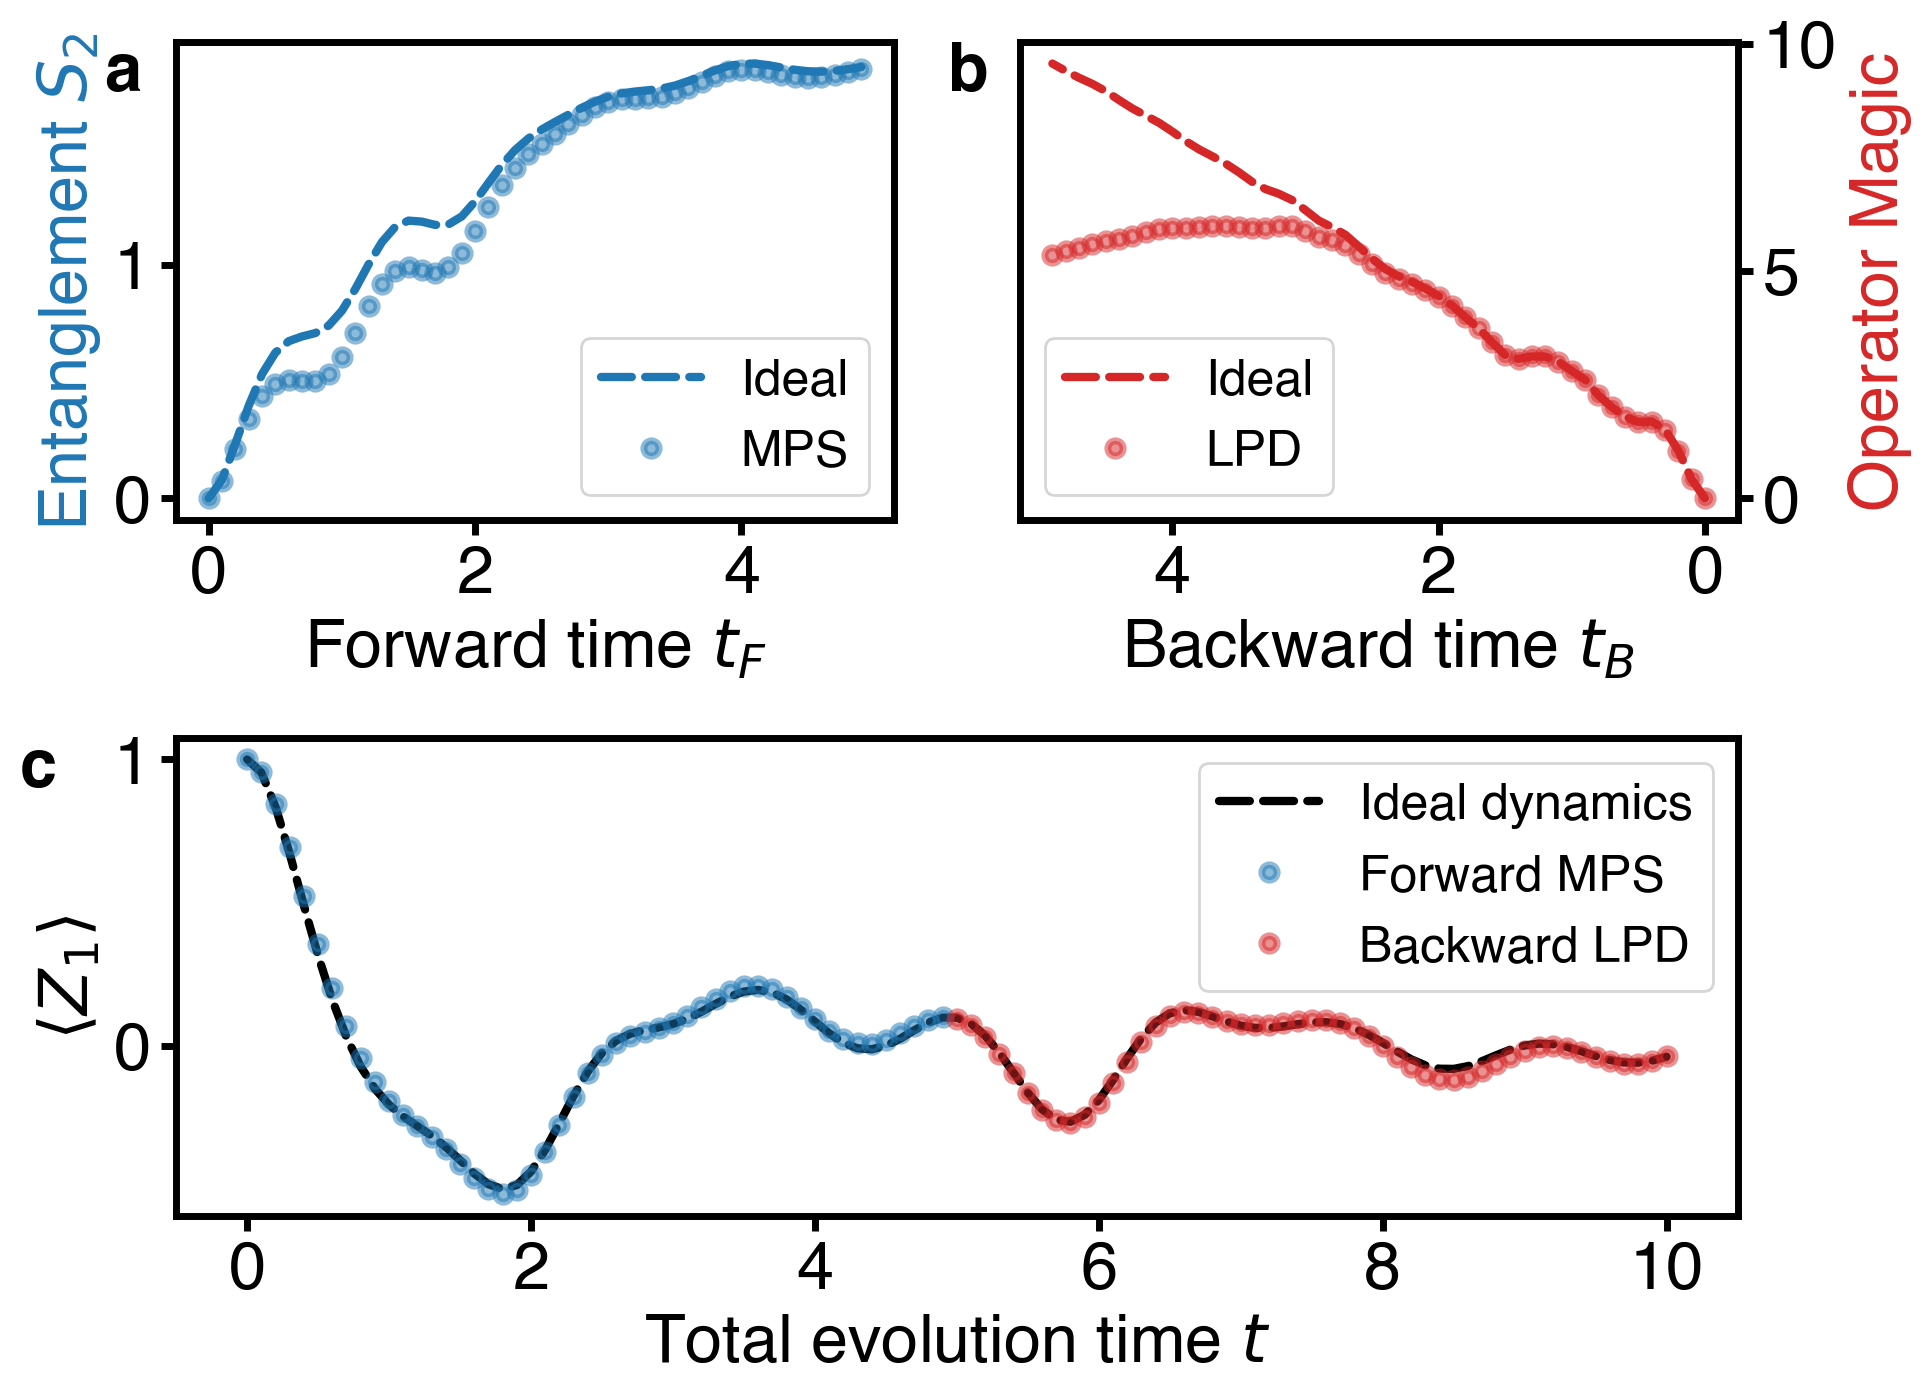

In [9]:
t_list = [i*dt for i in range(r+1)]
r2 = r//2

fig = plt.figure(figsize=(10, 10))
ax1 = plt.subplot(3, 2, 1)
ax2 = plt.subplot(3, 2, 2)
# Create the wide rectangular plot in the second row (spanning both columns)
ax3 = plt.subplot(3, 1, 2)
# ax4 = plt.subplot(3, 1, 3, sharex=ax3)

ax1.plot(t_list[:r2], qmfi_entangle_entropy3[:r2], '--', label='Ideal', c='tab:blue')
ax1.plot(t_list[:r2], qmfi_entangle_entropy3_mps[:r2], '.', label='MPS', c='tab:blue', alpha=0.5, markeredgecolor='tab:blue', markeredgewidth=2.5)
ax1.set_ylabel(rf'Entanglement $S_{sub_dim}$', c='tab:blue')
ax1.set_xlabel(rf'Forward time $t_F$'); ax1.legend(loc='lower right')
ax2.plot(t_list[:r2], qmfi_magic_full[:r2], '--', label='Ideal', c='tab:red')
ax2.plot(t_list[:r2], qmfi_magic[:r2], '.', label='LPD', c='tab:red', alpha=0.5, markeredgecolor='tab:red', markeredgewidth=2.5)
ax2.invert_xaxis(); ax2.legend(loc='lower left')
ax2.set_ylabel('Operator Magic', c='tab:red')
ax2.set_xlabel(rf'Backward time $t_B$')
ax2.yaxis.set_label_position("right")  # Move y-axis label to the right
ax2.yaxis.tick_right()

ax3.plot(t_list, qmfi_ideal_expvals, '--', label='Ideal dynamics', c='k')
# ax3.plot(t_list[:r2], qmfi_trott_expvals[:r2], '.-', label='Forward MPS', c='tab:blue')
ax3.plot(t_list[:r2], expvals_mps16[:r2], '.', label='Forward MPS', c='tab:blue', alpha=0.5, markeredgecolor='tab:blue', markeredgewidth=2.5)
# ax3.plot(t_list[r2:], qmfi_trott_expvals[r2:], '.-', label='Backward LPD', c='tab:blue')
ax3.plot(t_list[r2:], hybrid_expvals, '.', label='Backward LPD', c='tab:red', alpha=0.5, markeredgecolor='tab:red', markeredgewidth=2.5)
ax3.set_ylabel(rf'$\langle Z_1 \rangle$'); ax3.legend(loc='upper right')
ax3.set_xlabel(rf'Total evolution time $t$')
# ax3.tick_params(labelbottom=False)
# ax4.plot(t_list, np.abs(np.array(qmfi_ideal_expvals)-np.array(qmfi_trott_expvals)), '.-', label='Trotter', c='tab:green')
# ax4.plot(t_list, np.abs(np.array(qmfi_trott_expvals)-np.array(expvals_mps16)), '.-', label='MPS', c='tab:red')
# ax4.set_xlabel(rf'Total evolution time $t$')
# ax4.set_ylabel('Errors'); ax4.legend()
# plt.subplots_adjust(hspace=0.15)
for ax, label in zip([ax1, ax2, ax3], ['a', 'b', 'c']): 
# for ax, label in zip([ax1, ax2, ax3, ax4], ['a', 'b', 'c', 'd']): 
    ax.text(-0.10, 1.00, label, transform=ax.transAxes, fontsize=24, va='top', weight='bold')

fig.savefig(f'{fig_dir}/hybrid_n={n}_t={t}_r={r}.pdf', bbox_inches='tight')

In [185]:
qmfi_norm_weight_steps_full = [weight_2norm_distr(ob, n) for ob in qmfi_sim_full.evo_obs]
qmfi_norm_weight_steps = [weight_2norm_distr(ob, n) for ob in qmfi_sim.evo_obs]

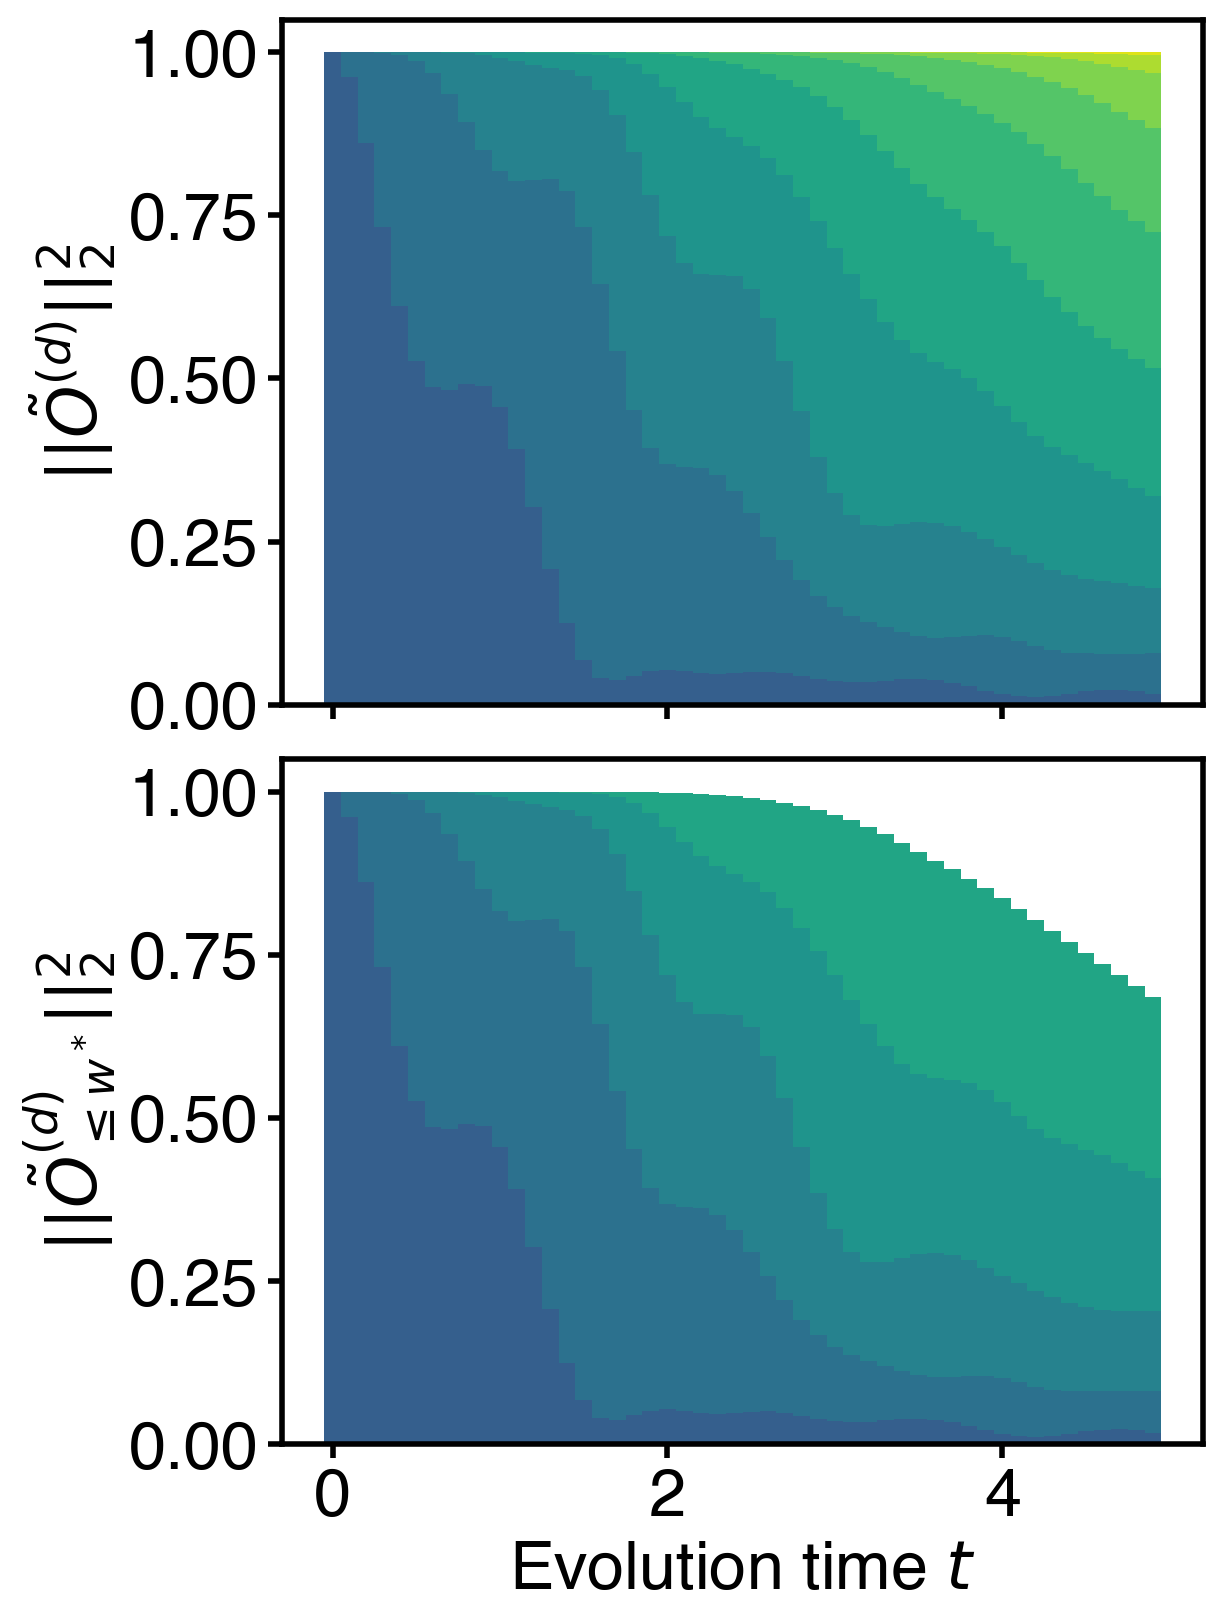

In [204]:
fig, axes = plt.subplots(2, 1, figsize=(6, 8), sharex=True, layout='constrained')
colors = plt.cm.viridis(np.linspace(0.3, 0.95, n))

for w in range(n, 0, -1):
    norm2_distr = [sum(qmfi_norm_weight_steps[i][:w]) for i in range(r2)]
    # if w<=7: print(f'w>={w+1},', 1-norm2_distr[-1])
    bars = axes[1].bar(t_list[:r2], norm2_distr, 0.1, color=colors[w-1], label=f'w<={w}')
    axes[1].set_ylabel(r'$||\tilde{O}_{\leq w^*}^{(d)}||_2^2$') # axes[1,0].legend(loc='upper right')

    norm2_distr_full = [sum(qmfi_norm_weight_steps_full[i][:w]) for i in range(r2)]
    axes[0].bar(t_list[:r2], norm2_distr_full, 0.1, color=colors[w-1], label=f'w<={w}')
    axes[0].set_ylabel(r'$||\tilde{O}^{(d)}||_2^2$') # axes[0,0].legend(loc='upper right')

axes[1].set_xlabel(r'Evolution time $t$')
# for ax, label in zip(axes.flatten(), ['a', 'b', 'c', 'd']): 
#     ax.text(-0.25, 1.00, label, transform=ax.transAxes, fontsize=24, va='top', weight='bold')

fig.savefig(f'{fig_dir}/LPD_2norm_distr_n={n}_t={t}_r={r}_w={w_thres}.pdf', bbox_inches='tight')

Text(0.5, 0, 'Evolution time $t$')

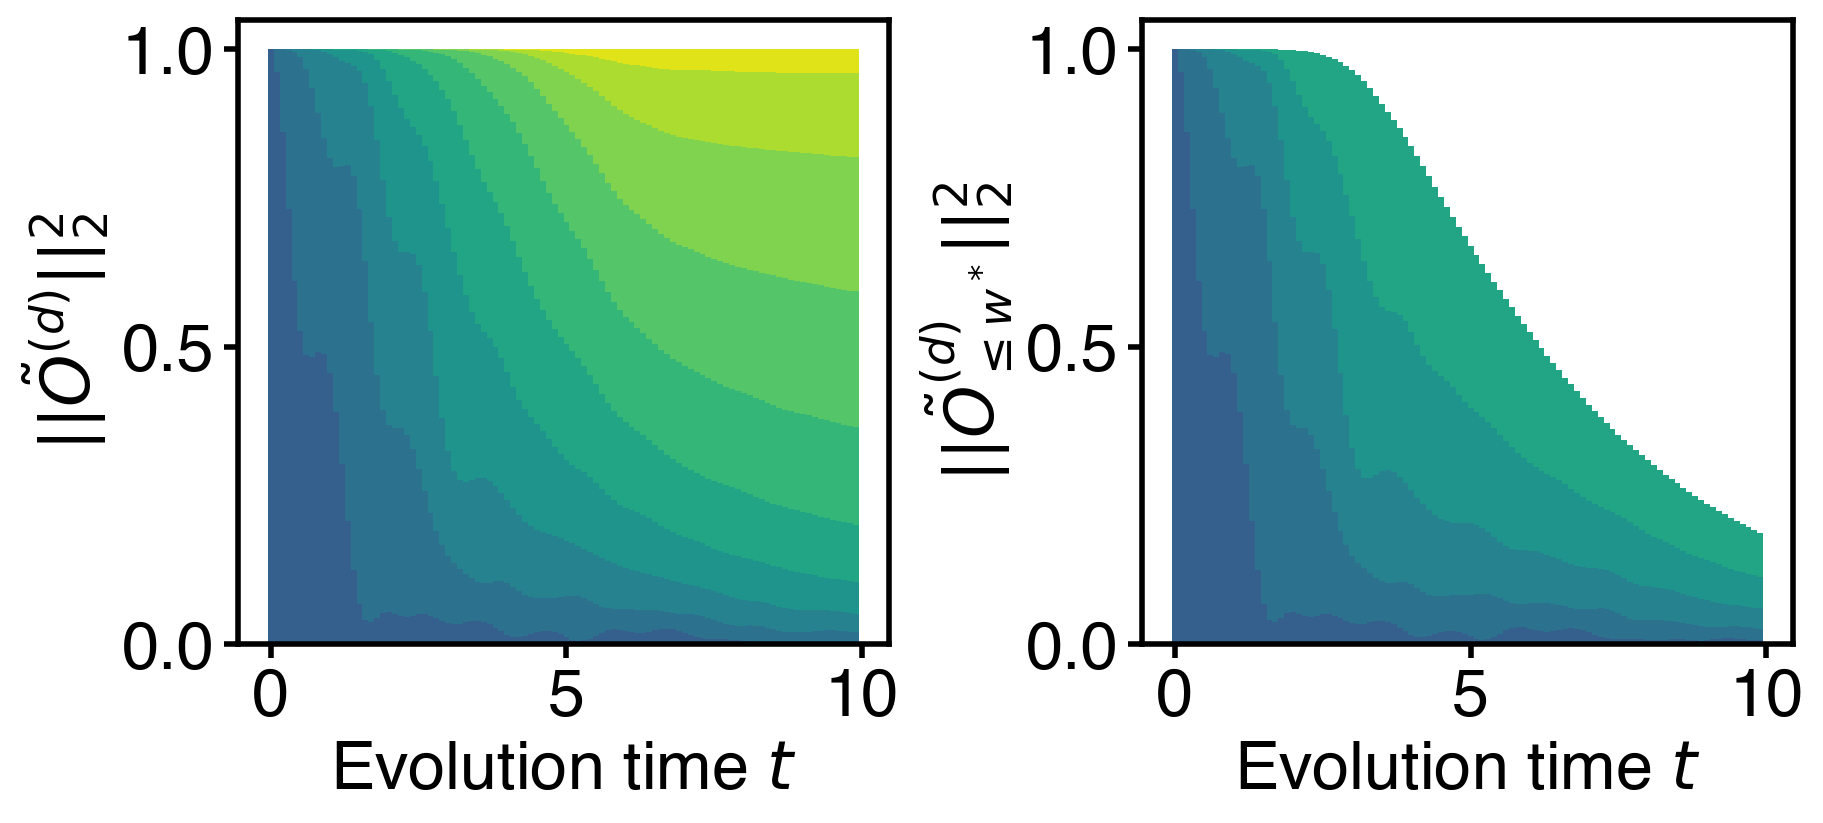

In [212]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, layout='constrained')
colors = plt.cm.viridis(np.linspace(0.3, 0.95, n))

r3 = int(r2*2.0)
for w in range(n, 0, -1):
    norm2_distr = [sum(qmfi_norm_weight_steps[i][:w]) for i in range(r3)]
    bars = axes[1].bar(t_list[:r3], norm2_distr, 0.1, color=colors[w-1], label=f'w<={w}')
    axes[1].set_ylabel(r'$||\tilde{O}_{\leq w^*}^{(d)}||_2^2$') # axes[1,0].legend(loc='upper right')

    norm2_distr_full = [sum(qmfi_norm_weight_steps_full[i][:w]) for i in range(r3)]
    axes[0].bar(t_list[:r3], norm2_distr_full, 0.1, color=colors[w-1], label=f'w<={w}')
    axes[0].set_ylabel(r'$||\tilde{O}^{(d)}||_2^2$') # axes[0,0].legend(loc='upper right')

axes[0].set_xlabel(r'Evolution time $t$')
axes[1].set_xlabel(r'Evolution time $t$')

# fig.savefig(f'{fig_dir}/LPD_2norm_distr_n={n}_t={t}_r={r}_w={w_thres}.pdf', bbox_inches='tight')